<a href="https://colab.research.google.com/github/lingyixu/BA770-Lab-Materials/blob/master/chapters/chapter17/code/Chapter17_Foreign_Exchange_Markets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Remark:
* 17.3.2 Need a permanent path for the calibrated vol table.
* Fix the \index ref.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import root, minimize
import yfinance as yf
import matplotlib.pyplot as plt

!pip install pyfinance
from pyfinance.options import BSM

### 17.2.6 Black-Scholes Model in an FX Setting

In this coding example, we show how this modified version of the Black-Scholes model can be used to price vanilla call options on an exchange rate:

In [2]:
def fxBsCall(S0, K, sigma, r_d, r_f, T):
    F = S0 * np.exp ((r_d - r_f) * T)
    d1 = (1/(sigma*np.sqrt(T))) * (np.log(F/K) + 0.5*(sigma**2)*T)
    d2 = d1 - sigma*np.sqrt(T)
    pxCall = np.exp(-r_d*T) * (F*norm.cdf(d1) - K*norm.cdf(d2))
    return pxCall

In [3]:
S0, K, sigma, r_d, r_f, T = 1.2, 1.25, 0.1, 0.02, 0.05, 1
print('Price of the FX rate call option of the domestic currency: {}'.format(fxBsCall(S0, K, sigma, r_d, r_f, T)))

Price of the FX rate call option of the domestic currency: 0.016651425048556594


The reader should note that the risk-free rate in this Black-Scholes pricing formula should correspond to the risk-free rate of the domestic currency \index{Currency!Domestic Currency}.

### 17.3.2 FX Volatility Surfaces in Practice: Comparison across Currency Pairs

The following volatility table is derived from calibration. Readers shall feel free to use it as given.

In [4]:
df_vol_surface = pd.read_excel('volSurfaces3MCombined.xlsx', index_col=0)
df_vol_surface

,CADMXN,CHFRUB,GBPAUD,USDBRL,USDEUR
Delta Call,,,,,
0.05,0.13247,0.18791,0.08504,0.22848,0.06069
0.10,0.12471,0.17629,0.08001,0.21796,0.05858
0.25,0.10877,0.14627,0.07170,0.19349,0.05533
0.50,0.09664,0.12160,0.06640,0.17182,0.05348
0.75,0.09179,0.11020,0.06640,0.15936,0.05418
0.90,0.09158,0.10607,0.06999,0.15344,0.05633
0.95,0.09232,0.10479,0.07276,0.15102,0.05789


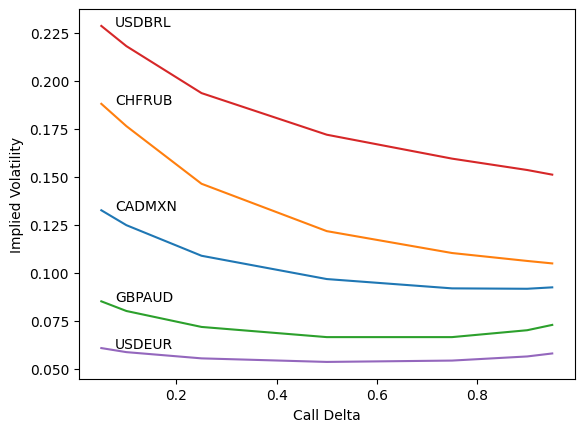

In [6]:
df_vol_surface.plot(legend=False)

for i in range(len(df_vol_surface.columns)):
    currency_pair = df_vol_surface.columns[i]
    plt.annotate(currency_pair,
                 (df_vol_surface.index[0], df_vol_surface.iloc[0,i]),
                 textcoords="offset points",
                 xytext=(10,0),
                 ha='left', fontsize=10)

plt.xlabel('Call Delta')
plt.ylabel('Implied Volatility')
plt.show()

### 17.4.1 Digital Options; 17.4.2 One Touch Options

In the following coding example, we detail how digital and one-touch prices can be computed given a set of simulated \index{Simulation} paths:

In [ ]:
def priceDigiCall(paths, K, r, T):
    """paths: 2D np array, each subarray represents a period in time"""
    terminalVals = paths[-1]
    payoffs = np.where(terminalVals > K, 1, 0)
    return np.exp(-r*T)*np.mean(payoffs)

def priceOneTouchCall(paths, K, r, T):
    """paths: 2D np array, each subarray represents a period in time"""
    maxVals = np.max(paths, axis = 0)
    payoffs = np.where(maxVals > K, 1, 0)
    return np.exp(-r*T)*np.mean(payoffs)

For more details on how to build the code to generate the underlying simulated paths, the reader is encouraged to refer to the coding examples in chapter \ref{chExoticOptionTechniques}.

### 17.4.3 One-Touches vs. Digis in Practice: Ratio of Prices in EURJPY

In [ ]:
# import functions from previous chapters
def sabr_normal_vol(S_0,K,T,sigma_0,alpha,beta,rho):
    c = lambda x: x**beta
    c_prime = lambda x: beta*(x**(beta-1))
    c_prime_prime = lambda x: beta*(beta-1)*(x**(beta-2))
    S_mid = (S_0 + K)/2
    gamma_1 = c_prime(S_mid)/c(S_mid)
    gamma_2 = c_prime_prime(S_mid)/c(S_mid)
    zeta = alpha*(S_0**(1-beta) - K**(1-beta))/(sigma_0 * (1-beta))
    epsilon = T*(alpha**2)
    delta = np.log( (np.sqrt(1 - 2*rho*zeta + zeta**2) + zeta - rho)/(1-rho) )

    factor = alpha*(S_0 - K)/(delta)
    term_1 = ((2*gamma_2 - gamma_1**2)/24)* (sigma_0*c(S_mid)  / alpha)**2
    term_2 = rho*gamma_1*sigma_0*c(S_mid)/(4*alpha)
    term_3 = (2-3*(rho**2))/24
    return factor*(1 + epsilon*(term_1 + term_2 + term_3))

def bachelier_call(S_0,K,T,sigma,r):
    d_plus = (S_0*np.exp(r*T) - K)/(sigma*np.sqrt(T))
    return np.exp(-r*T)*sigma*np.sqrt(T)*(d_plus*norm.cdf(d_plus) + norm.pdf(d_plus))

def get_implied_vol_bs(S_0,K,T,r,observed_px, initial_guess):
    root_fn = lambda x: bs_call(S_0,K,T,x,r) - observed_px
    return root(root_fn,initial_guess)['x'][0]

def bs_call(S_0,K,T,sigma,r):
    d_1 = (np.log(S_0/K) + T*(r + (sigma**2)/2))/(sigma*np.sqrt(T))
    d_2 = d_1 - sigma*np.sqrt(T)
    return S_0*norm.cdf(d_1) - K*np.exp(-r*T)*norm.cdf(d_2)

In [ ]:
# define the objective function
def bs_sabr_vol(F_0, K, T, sigma_0, beta, alpha, rho):
    normVol = sabr_normal_vol(F_0, K, T, beta, sigma_0, alpha, rho)
    normPx = bachelier_call(F_0, K, T, normVol, 0.0)
    impVol = get_implied_vol_bs(F_0, K, T, 0.0, normPx, 0.2)
    return impVol

def strikeGivenDelta(F_0, T, rDom, rFor, delta, sigma):
    K = F_0 * np.exp(-sigma*np.sqrt(T)*norm.ppf(delta) + 0.5*(sigma**2)*T);
    return K

def sabrDeltForStrike(F_0, T, K, sigma_0, alpha, beta, rho, isPut):
    impVol = bs_sabr_vol(F_0, T, K, sigma_0, beta, alpha, rho)
    d1 = (1/(impVol*np.sqrt(T))) * ( np.log(F_0/K) + 0.5*(impVol**2)*T )

    if isPut > 0:
        delta = -norm.cdf(-d1)
    else:
        delta = norm.cdf(d1)
    return delta

def getStrikeGivenDeltaSABRSmile(F_0, T, sigma_0, alpha, beta, rho, isPut, deltaHat, initial_guess):
    root_fn = lambda x: sabrDeltForStrike(F_0, T, x, sigma_0, alpha, beta, rho, isPut) - deltaHat
    return root(root_fn, initial_guess)['x'][0]

def objectiveFunctionFX(params, beta, F_0, T, K_atm, K_c_st, K_p_st, rDom, rFor, sigma_atm, rr_vol, st_px):

    # extract the 25D risk reversal strikes
    K_c_rr = getStrikeGivenDeltaSABRSmile(F_0, T, params[0], params[1], beta, params[2], 0, 0.25, K_c_st)
    K_p_rr = getStrikeGivenDeltaSABRSmile(F_0, T, params[0], params[1], beta, params[2], 1, -0.25, K_p_st)

    # check the pricing error
    sigma_atm_hat = bs_sabr_vol(F_0, K_atm, T, params[0], beta, params[1], params[2])
    atm_error = (sigma_atm - sigma_atm_hat)**2

    sigma_rr_c_hat = bs_sabr_vol(F_0, K_c_rr, T, params[0], beta, params[1], params[2])
    sigma_rr_p_hat = bs_sabr_vol(F_0, K_p_rr, T, params[0], beta, params[1], params[2])
    rr_vol_hat = sigma_rr_c_hat - sigma_rr_p_hat
    rr_error = (rr_vol - rr_vol_hat)**2

    sigma_st_c_hat = bs_sabr_vol(F_0, K_c_st, T, params[0], beta, params[1], params[2])
    sigma_st_p_hat = bs_sabr_vol(F_0, K_p_st, T, params[0], beta, params[1], params[2])
    px_st_c_hat = np.exp(-r_d*T)*BSM(kind='call', S0=F_0, K = K_st_c, T = T, r = 0.00, sigma = sigma_atm+strangle_offset).value()
    px_st_p_hat = np.exp(-r_d*T)*BSM(kind='put', S0=F_0, K = K_st_p, T = T, r = 0.00, sigma = sigma_atm+strangle_offset).value()
    st_px_hat = (px_st_c_hat + px_st_p_hat)
    st_error = (st_px - st_px_hat)**2

    error = atm_error + rr_error + st_error
    return error

In [ ]:
# input data
F_0, r_d, r_f, T = 100.0, 0.015, 0.005, 0.5
sigma_atm, sigma_rr, strangle_offset = 0.2, 0.04, 0.025

# extract the ATM strike
delta = 0.5
K_atm = strikeGivenDelta(F_0, T, r_d, r_f, delta, sigma_atm)

# extract the 25D strangle strikes
delta1, delta2 = 0.25, 0.75
K_st_c = strikeGivenDelta(F_0, T, r_d, r_f, delta1, sigma_atm+strangle_offset)
K_st_p = strikeGivenDelta(F_0, T, r_d, r_f, delta2, sigma_atm+strangle_offset)

# calculate 25D strangle price
st_c_px = np.exp(-r_d*T)*BSM(kind='call', S0=F_0, K = K_st_c, T = T, r = 0.00, sigma = sigma_atm+strangle_offset).value()
st_p_px = np.exp(-r_d*T)*BSM(kind='put', S0=F_0, K = K_st_p, T = T, r = 0.00, sigma = sigma_atm+strangle_offset).value()
st_px = st_c_px + st_p_px

# optimization
beta = 0.5
results = minimize(objectiveFunctionFX,
                  x0 = [0.15,0.5,0],
         	        # bounds = ((0.00001, F_0),(0.00001, 10),(-1,1)),
                   bounds = ((0.00001, 0.5),(0.00001, 0.5),(-1,1)),
         	        args = (beta, F_0, T, K_atm, K_st_c, K_st_p, r_d, r_f, sigma_atm, sigma_rr, st_px),
         	        tol = 1e-14,
         	        method = 'SLSQP',
         	        options={'maxiter': 400, 'ftol': 1e-14})['x']

print(f'sigma_0 = {results[0]} \nalpha = {results[1]} \nrho = {results[2]}')

<ipython-input-2-89f58ccfffb6>:20: RuntimeWarning: invalid value encountered in sqrt
  d_plus = (S_0*np.exp(r*T) - K)/(sigma*np.sqrt(T))
<ipython-input-2-89f58ccfffb6>:21: RuntimeWarning: invalid value encountered in sqrt
  return np.exp(-r*T)*sigma*np.sqrt(T)*(d_plus*norm.cdf(d_plus) + norm.pdf(d_plus))
<ipython-input-2-89f58ccfffb6>:28: RuntimeWarning: invalid value encountered in sqrt
  d_1 = (np.log(S_0/K) + T*(r + (sigma**2)/2))/(sigma*np.sqrt(T))
<ipython-input-2-89f58ccfffb6>:29: RuntimeWarning: invalid value encountered in sqrt
  d_2 = d_1 - sigma*np.sqrt(T)
<ipython-input-3-d03cf5a6f149>:14: RuntimeWarning: invalid value encountered in log
  d1 = (1/(impVol*np.sqrt(T))) * ( np.log(F_0/K) + 0.5*(impVol**2)*T )


sigma_0 = 0.1499140978591602 
alpha = 0.4989660473922748 
rho = -0.001694045682477599


As is customary in a SABR model calibration, the parameter $\beta$ is set to a constant, due to its correlation with $\rho$, and the remaining three parameters are calibrated.

Now we simulate paths for the currency pair EURJPY using the calibrated SABR model:

In [ ]:
def sabr_simu(F0, T, sigma_0, alpha, rho, beta=0.5, n_paths=1000, n_steps=100):

    dt = T / n_steps
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = F0

    np.random.seed(42)
    for i in range(n_paths):
        for j in range(1, n_steps + 1):
            z = np.random.normal(size=2)
            dW1, dW2 = z[0] * np.sqrt(dt), rho * z[0] * np.sqrt(dt) + np.sqrt(1 - rho**2) * z[1] * np.sqrt(dt)
            sigma = sigma_0 * (1 + alpha * max(0, (paths[i, j-1] - F0)) ** beta)
            paths[i, j] = paths[i, j-1] * np.exp(-0.5 * sigma ** 2 * dt + sigma * dW1)

    return paths

def calculate_price_ratio(F0, T, sigma_0, alpha, rho, K, r, beta=0.5, n_paths=1000, n_steps=100):

    paths = sabr_simu(F0, T, sigma_0, alpha, rho, beta, n_paths, n_steps)
    digital_price = priceDigiCall(paths, K, r, T)
    one_touch_option_price = priceOneTouchCall(paths, K, r, T)

    return one_touch_option_price / digital_price

These functions could be used to generate the price of lookbacks given the calibrated SABR model.